In [2860]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score


In [2861]:
data = pd.read_csv('ai_job_dataset.csv')

### EDA

In [2862]:
data

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


In [2863]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

<Axes: >

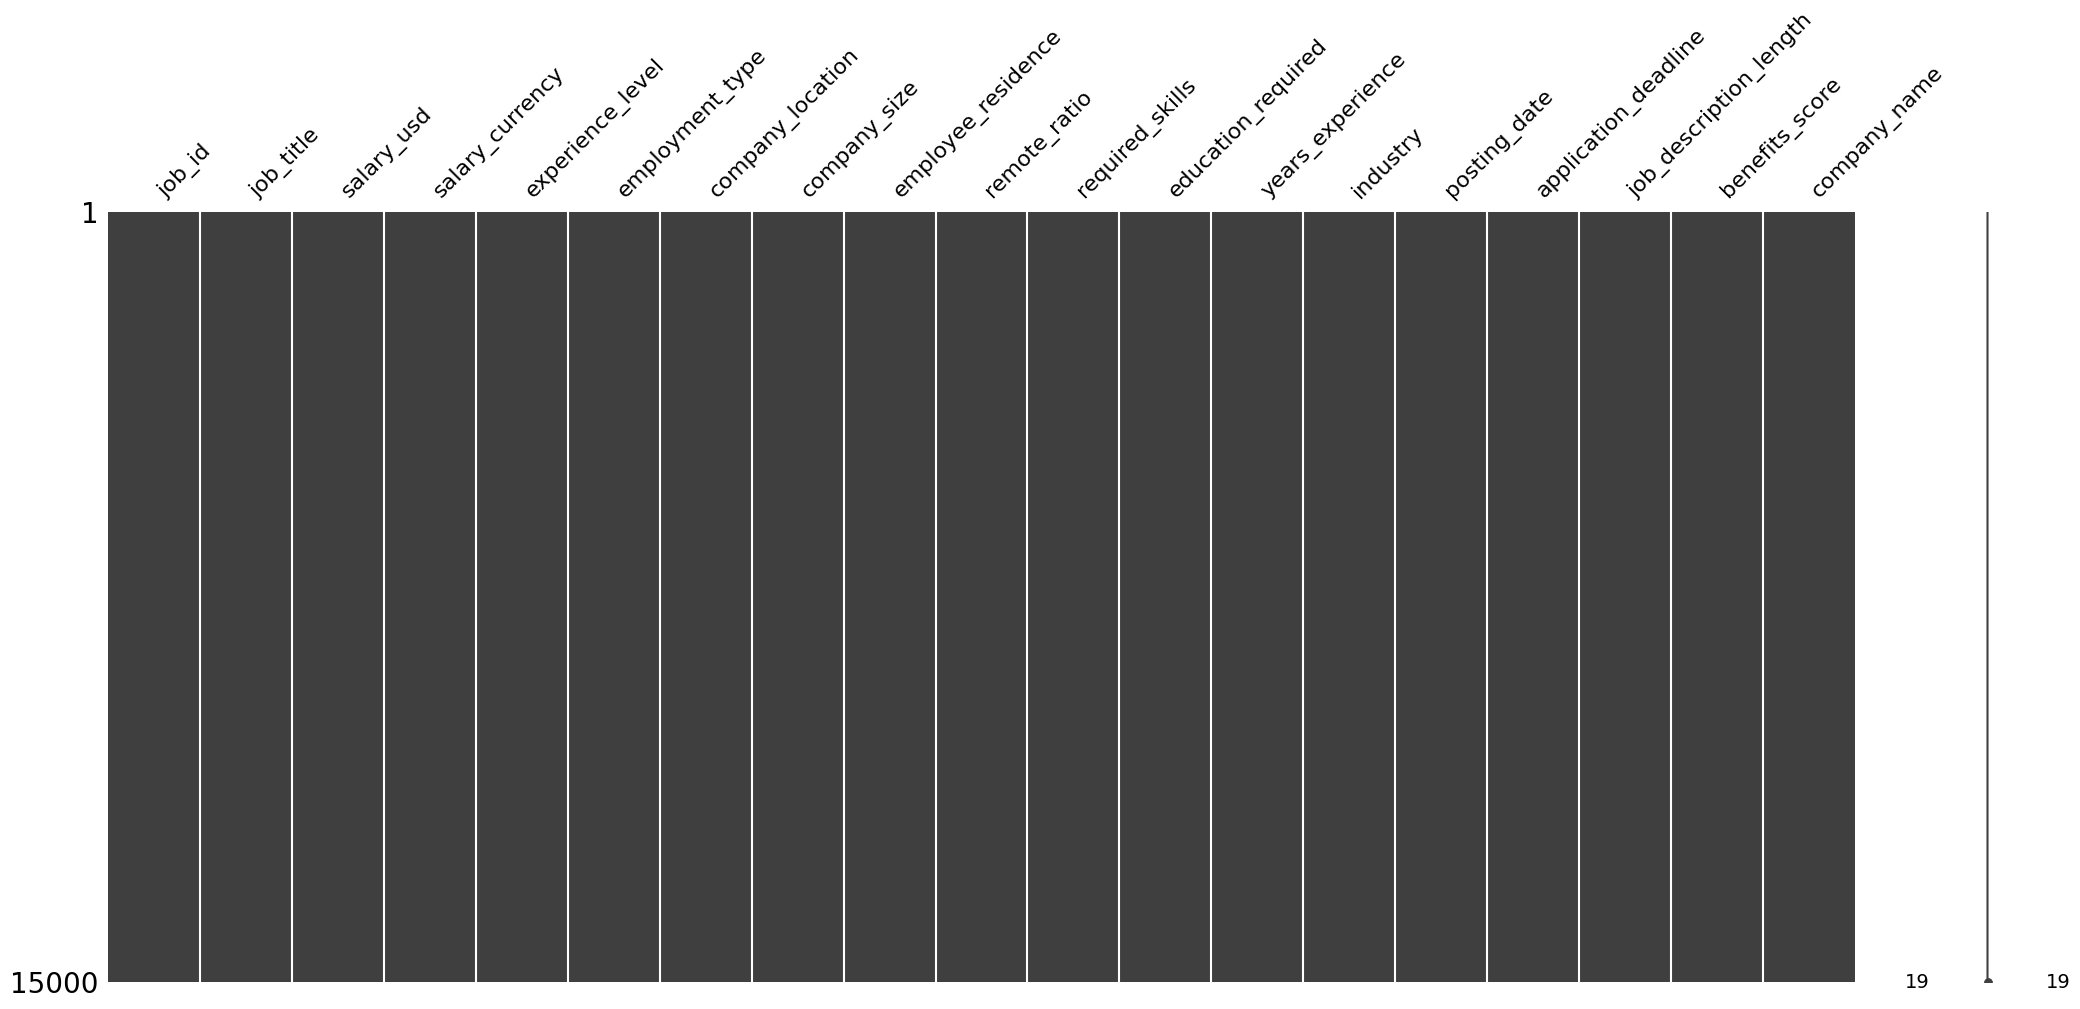

In [2864]:
msno.matrix(data)

In [2865]:
data.duplicated().sum()

np.int64(0)

In [2866]:
data.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [2867]:
# checking for unique values to check what to standardize
for col in data.columns:
    print(f"column: {col} \nnumber of unique values: {data[col].nunique()} \n{data[col].unique()} \n")

column: job_id 
number of unique values: 15000 
['AI00001' 'AI00002' 'AI00003' ... 'AI14998' 'AI14999' 'AI15000'] 

column: job_title 
number of unique values: 20 
['AI Research Scientist' 'AI Software Engineer' 'AI Specialist'
 'NLP Engineer' 'AI Consultant' 'AI Architect' 'Principal Data Scientist'
 'Data Analyst' 'Autonomous Systems Engineer' 'AI Product Manager'
 'Machine Learning Engineer' 'Data Engineer' 'Research Scientist'
 'ML Ops Engineer' 'Robotics Engineer' 'Head of AI'
 'Deep Learning Engineer' 'Data Scientist' 'Machine Learning Researcher'
 'Computer Vision Engineer'] 

column: salary_usd 
number of unique values: 14315 
[ 90376  61895 152626 ... 189490  79461  56481] 

column: salary_currency 
number of unique values: 3 
['USD' 'EUR' 'GBP'] 

column: experience_level 
number of unique values: 4 
['SE' 'EN' 'MI' 'EX'] 

column: employment_type 
number of unique values: 4 
['CT' 'FL' 'PT' 'FT'] 

column: company_location 
number of unique values: 20 
['China' 'Canada' 'Swi

### Feature Engineering

In [2868]:
# Removing israel and israelians 
data = data[data['company_location'] != 'Israel']
data = data[data['employee_residence'] != 'Israel']

In [2869]:
# Dropping unnecessary columns 
data.drop(columns = ['job_id', 'job_description_length', 'application_deadline', 'employee_residence'], axis = 1 , inplace = True)

In [2870]:
# Mapping shortened Columns to their Original values

experience_level_values = {'EN': 'Entry',
                           'MI': 'Mid',
                           'SE': 'Senior',
                           'EX': 'Executive'}
data['experience_level'] = data['experience_level'].map(experience_level_values)

employment_type_values = {'FT': 'Full-time', 
                          'PT': 'Part-time', 
                          'CT': 'Contract',
                          'FL': 'Freelance'}
data['employment_type'] = data['employment_type'].map(employment_type_values)

company_size_values = {'S': 'Small <50', 
                       'M': 'Medium 50-250',
                       'L': 'Large >250'}
data['company_size'] = data['company_size'].map(company_size_values)

data['job_type'] = data['remote_ratio'].map({100: 'Remote', 50: 'Hybrid', 0: 'On-Site'})
data.drop('remote_ratio', axis = 1, inplace = True)

In [2871]:
data.head()

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,required_skills,education_required,years_experience,industry,posting_date,benefits_score,company_name,job_type
0,AI Research Scientist,90376,USD,Senior,Contract,China,Medium 50-250,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,5.9,Smart Analytics,Hybrid
1,AI Software Engineer,61895,USD,Entry,Contract,Canada,Medium 50-250,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,5.2,TechCorp Inc,Remote
2,AI Specialist,152626,USD,Mid,Freelance,Switzerland,Large >250,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,9.4,Autonomous Tech,On-Site
3,NLP Engineer,80215,USD,Senior,Freelance,India,Medium 50-250,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,8.6,Future Systems,Hybrid
4,AI Consultant,54624,EUR,Entry,Part-time,France,Small <50,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,6.6,Advanced Robotics,Remote


In [2872]:
# Standardizing the salary in USD currency according to today's values
currency_to_USD = {'EUR': 1.18, # Euro
                   'GBP': 1.35} # Pound

# EUR to USD
eur_mask = data['salary_currency'] == 'EUR'
data.loc[eur_mask, 'salary_usd'] = data.loc[eur_mask, 'salary_usd'] * currency_to_USD['EUR']
data.loc[eur_mask, 'salary_currency'] = 'USD'  

# GBP to USD
gbp_mask = data['salary_currency'] == 'GBP'
data.loc[gbp_mask, 'salary_usd'] = data.loc[gbp_mask, 'salary_usd'] * currency_to_USD['GBP']
data.loc[gbp_mask, 'salary_currency'] = 'USD'  

data['salary_usd'] = data['salary_usd'].astype(int)
data.drop('salary_currency', axis = 1, inplace = True)

/var/folders/4t/t77snq8s3_55d_nd3dpn2_cw0000gn/T/ipykernel_97654/1558387663.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 64456.32 145817.32  83355.2  ... 168953.58 156767.72  93763.98]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[eur_mask, 'salary_usd'] = data.loc[eur_mask, 'salary_usd'] * currency_to_USD['EUR']


In [2873]:
# Modifying date feature to only hold year and month
data['posting_date'] = pd.to_datetime(data['posting_date'])

data['posting_year_month'] = data['posting_date'].dt.to_period('M')  

data['posting_date'] = data['posting_year_month']
data.drop('posting_year_month', axis = 1, inplace = True)

In [2874]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14043 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   job_title           14043 non-null  object   
 1   salary_usd          14043 non-null  int64    
 2   experience_level    14043 non-null  object   
 3   employment_type     14043 non-null  object   
 4   company_location    14043 non-null  object   
 5   company_size        14043 non-null  object   
 6   required_skills     14043 non-null  object   
 7   education_required  14043 non-null  object   
 8   years_experience    14043 non-null  int64    
 9   industry            14043 non-null  object   
 10  posting_date        14043 non-null  period[M]
 11  benefits_score      14043 non-null  float64  
 12  company_name        14043 non-null  object   
 13  job_type            14043 non-null  object   
dtypes: float64(1), int64(2), object(10), period[M](1)
memory usage: 1.6+ MB


In [2875]:
data

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,required_skills,education_required,years_experience,industry,posting_date,benefits_score,company_name,job_type
0,AI Research Scientist,90376,Senior,Contract,China,Medium 50-250,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10,5.9,Smart Analytics,Hybrid
1,AI Software Engineer,61895,Entry,Contract,Canada,Medium 50-250,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11,5.2,TechCorp Inc,Remote
2,AI Specialist,152626,Mid,Freelance,Switzerland,Large >250,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03,9.4,Autonomous Tech,On-Site
3,NLP Engineer,80215,Senior,Freelance,India,Medium 50-250,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12,8.6,Future Systems,Hybrid
4,AI Consultant,64456,Entry,Part-time,France,Small <50,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04,6.6,Advanced Robotics,Remote
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Robotics Engineer,38604,Entry,Freelance,Finland,Small <50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02,7.9,Advanced Robotics,Hybrid
14996,Machine Learning Researcher,78044,Entry,Contract,United Kingdom,Medium 50-250,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10,8.2,Smart Analytics,On-Site
14997,NLP Engineer,189490,Executive,Contract,South Korea,Large >250,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03,7.4,AI Innovations,Hybrid
14998,Head of AI,93763,Entry,Full-time,Netherlands,Medium 50-250,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03,5.6,Smart Analytics,On-Site


In [2876]:
# checking if there is columns with 80% of same value 
from collections import Counter

cols = data.columns
cols_over_80percent_same_value = []
for col in cols:
    column_values = list(data[col])
    cntr = Counter(column_values)
    for key, value in cntr.items():
        if (value / len(data)) * 100 >= 80:
            print(col, key, int(value / 14043) * 100)
            cols_over_80percent_same_value.append(col)
            
print(cols_over_80percent_same_value)

[]


array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

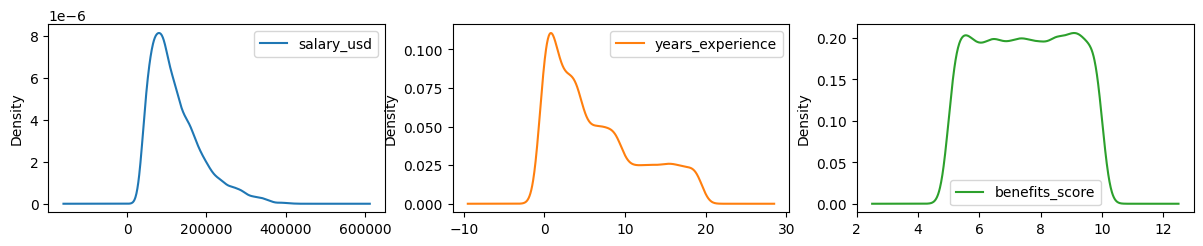

In [2877]:
# Checking for outliers
data.select_dtypes(include=[np.number]).plot(kind='density', subplots=True, layout=(7,4), figsize=(20,20), sharex=False)

salary_usd             Axes(0.125,0.786098;0.168478x0.0939024)
years_experience    Axes(0.327174,0.786098;0.168478x0.0939024)
benefits_score      Axes(0.529348,0.786098;0.168478x0.0939024)
dtype: object

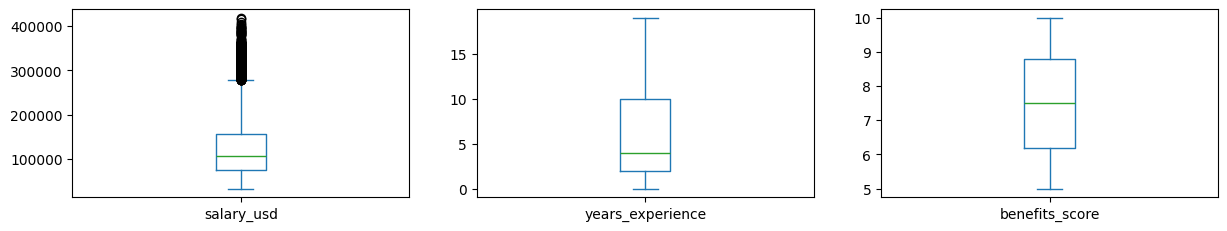

In [2878]:
data.select_dtypes(include=[np.number]).plot(kind='box', subplots=True, layout=(7,4), figsize=(20,20), sharex=False)

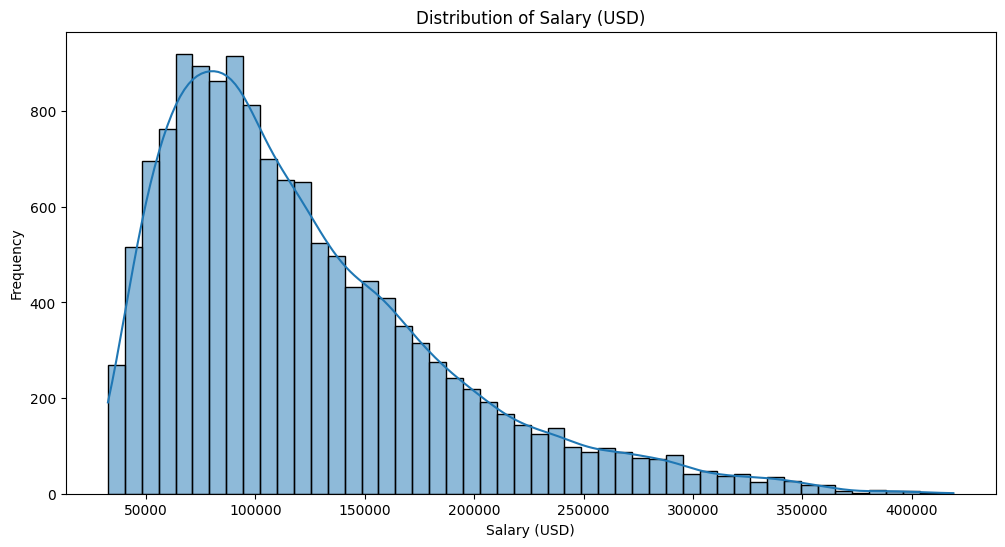

In [2879]:
plt.figure(figsize=(12,6))
sns.histplot(data['salary_usd'], bins=50, kde=True)
plt.title('Distribution of Salary (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

### Encoding the multi-valued feature

In [2880]:
# Multi-Label Encoding the required skills feature
all_skills = set()
for skill in data['required_skills'].dropna().str.split(', '):
    all_skills.update(skill)

In [2881]:
print(all_skills)

{'MLOps', 'NLP', 'Java', 'Computer Vision', 'Deep Learning', 'Data Visualization', 'Kubernetes', 'Statistics', 'Spark', 'AWS', 'Python', 'TensorFlow', 'Linux', 'Docker', 'Mathematics', 'GCP', 'Hadoop', 'R', 'Tableau', 'SQL', 'PyTorch', 'Azure', 'Scala', 'Git'}


In [2882]:
mlb = MultiLabelBinarizer()

skills_list = data['required_skills'].str.split(', ')
required_skills_encoded = mlb.fit_transform(skills_list)
skills_df = pd.DataFrame(required_skills_encoded, columns=mlb.classes_, index=data.index)

data = pd.concat([data, skills_df], axis=1) 
data.drop('required_skills', axis=1, inplace=True) 

In [2883]:
data

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,education_required,years_experience,industry,posting_date,...,NLP,PyTorch,Python,R,SQL,Scala,Spark,Statistics,Tableau,TensorFlow
0,AI Research Scientist,90376,Senior,Contract,China,Medium 50-250,Bachelor,9,Automotive,2024-10,...,1,1,0,0,0,0,0,0,1,0
1,AI Software Engineer,61895,Entry,Contract,Canada,Medium 50-250,Master,1,Media,2024-11,...,0,0,1,0,0,0,0,0,0,0
2,AI Specialist,152626,Mid,Freelance,Switzerland,Large >250,Associate,2,Education,2025-03,...,1,0,0,0,0,0,0,0,0,0
3,NLP Engineer,80215,Senior,Freelance,India,Medium 50-250,PhD,7,Consulting,2024-12,...,0,0,1,0,1,1,0,0,0,0
4,AI Consultant,64456,Entry,Part-time,France,Small <50,Master,0,Media,2025-04,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Robotics Engineer,38604,Entry,Freelance,Finland,Small <50,Bachelor,1,Energy,2025-02,...,0,0,0,0,0,0,0,0,0,0
14996,Machine Learning Researcher,78044,Entry,Contract,United Kingdom,Medium 50-250,Master,0,Government,2024-10,...,0,0,0,0,1,0,0,0,0,0
14997,NLP Engineer,189490,Executive,Contract,South Korea,Large >250,Associate,17,Manufacturing,2024-03,...,1,0,0,0,0,1,1,0,0,0
14998,Head of AI,93763,Entry,Full-time,Netherlands,Medium 50-250,PhD,1,Real Estate,2024-03,...,0,0,1,0,0,0,0,0,0,1


### Exporting data for visualization and power bi

In [2884]:
# Saving data for visualization and storytelling
data.to_csv('visualization_data.csv')

### Normalizing features

In [2885]:
# normalizing numerical columns
print(data[['salary_usd', 'years_experience']])

       salary_usd  years_experience
0           90376                 9
1           61895                 1
2          152626                 2
3           80215                 7
4           64456                 0
...           ...               ...
14995       38604                 1
14996       78044                 0
14997      189490                17
14998       93763                 1
14999       56481                 2

[14043 rows x 2 columns]


In [2886]:
data['salary_usd'] = np.log1p(data['salary_usd'])
data['years_experience'] = np.log1p(data['years_experience'])

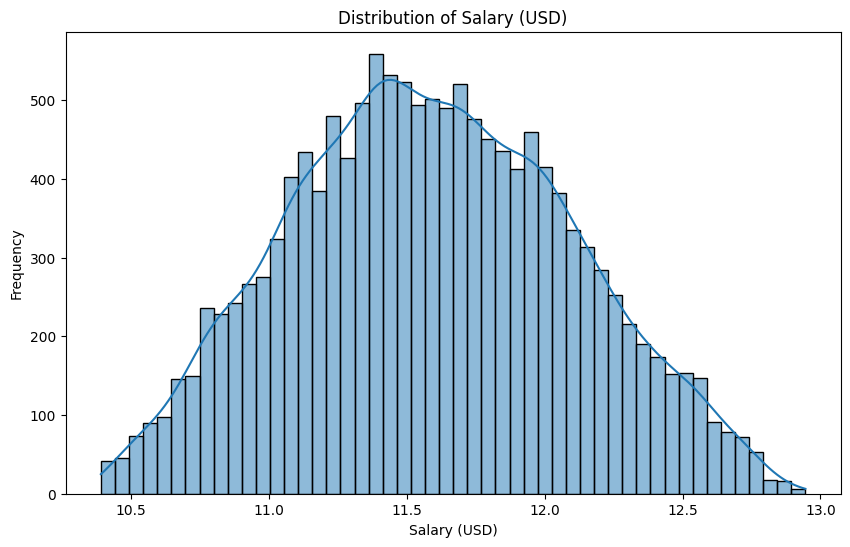

In [2887]:
plt.figure(figsize=(10,6))
sns.histplot(data['salary_usd'], bins=50, kde=True)
plt.title('Distribution of Salary (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

In [2888]:
data.head()

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,education_required,years_experience,industry,posting_date,...,NLP,PyTorch,Python,R,SQL,Scala,Spark,Statistics,Tableau,TensorFlow
0,AI Research Scientist,11.411745,Senior,Contract,China,Medium 50-250,Bachelor,2.302585,Automotive,2024-10,...,1,1,0,0,0,0,0,0,1,0
1,AI Software Engineer,11.033211,Entry,Contract,Canada,Medium 50-250,Master,0.693147,Media,2024-11,...,0,0,1,0,0,0,0,0,0,0
2,AI Specialist,11.935752,Mid,Freelance,Switzerland,Large >250,Associate,1.098612,Education,2025-03,...,1,0,0,0,0,0,0,0,0,0
3,NLP Engineer,11.292478,Senior,Freelance,India,Medium 50-250,PhD,2.079442,Consulting,2024-12,...,0,0,1,0,1,1,0,0,0,0
4,AI Consultant,11.073754,Entry,Part-time,France,Small <50,Master,0.000000,Media,2025-04,...,0,0,1,0,0,0,0,0,1,0


In [2889]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14043 entries, 0 to 14999
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   job_title           14043 non-null  object   
 1   salary_usd          14043 non-null  float64  
 2   experience_level    14043 non-null  object   
 3   employment_type     14043 non-null  object   
 4   company_location    14043 non-null  object   
 5   company_size        14043 non-null  object   
 6   education_required  14043 non-null  object   
 7   years_experience    14043 non-null  float64  
 8   industry            14043 non-null  object   
 9   posting_date        14043 non-null  period[M]
 10  benefits_score      14043 non-null  float64  
 11  company_name        14043 non-null  object   
 12  job_type            14043 non-null  object   
 13  AWS                 14043 non-null  int64    
 14  Azure               14043 non-null  int64    
 15  Computer Vision     1404

### Encoding Features

In [2890]:
# ordinal features encoding with the OrdinalEncoder
ordinal_columns = ['experience_level', 'company_size', 'education_required','posting_date']

data['experience_level'] = data['experience_level'].map({'Entry': 1, 'Mid': 2, 'Senior': 3, 'Executive': 4})
data['company_size'] = data['company_size'].map({'Small <50': 1, 'Medium 50-250': 2, 'Large >250': 3})
data['education_required'] = data['education_required'].map({'Associate': 1, 'Bachelor':2, 'Master': 3, 'PhD': 4})

date_ordinal_encoder = OrdinalEncoder()
data['posting_date'] = date_ordinal_encoder.fit_transform(data[['posting_date']])

In [2891]:
# encoding nominal features with LabelEncoder
nominal_columns = [col for col in data.columns if data[col].dtype == 'object']
print(nominal_columns)
le = LabelEncoder()
for col in nominal_columns:
    data[col] = le.fit_transform(data[col])


['job_title', 'employment_type', 'company_location', 'industry', 'company_name', 'job_type']


In [2892]:
data.head()

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,education_required,years_experience,industry,posting_date,...,NLP,PyTorch,Python,R,SQL,Scala,Spark,Statistics,Tableau,TensorFlow
0,3,11.411745,3,0,3,2,2,2.302585,0,9.0,...,1,1,0,0,0,0,0,0,1,0
1,4,11.033211,1,0,2,2,3,0.693147,9,10.0,...,0,0,1,0,0,0,0,0,0,0
2,5,11.935752,2,1,16,3,1,1.098612,2,14.0,...,1,0,0,0,0,0,0,0,0,0
3,16,11.292478,3,1,8,2,4,2.079442,1,11.0,...,0,0,1,0,1,1,0,0,0,0
4,1,11.073754,1,3,6,1,3,0.000000,9,15.0,...,0,0,1,0,0,0,0,0,1,0


In [2893]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14043 entries, 0 to 14999
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           14043 non-null  int64  
 1   salary_usd          14043 non-null  float64
 2   experience_level    14043 non-null  int64  
 3   employment_type     14043 non-null  int64  
 4   company_location    14043 non-null  int64  
 5   company_size        14043 non-null  int64  
 6   education_required  14043 non-null  int64  
 7   years_experience    14043 non-null  float64
 8   industry            14043 non-null  int64  
 9   posting_date        14043 non-null  float64
 10  benefits_score      14043 non-null  float64
 11  company_name        14043 non-null  int64  
 12  job_type            14043 non-null  int64  
 13  AWS                 14043 non-null  int64  
 14  Azure               14043 non-null  int64  
 15  Computer Vision     14043 non-null  int64  
 16  Data Visu

### Checking correlation and heatmap

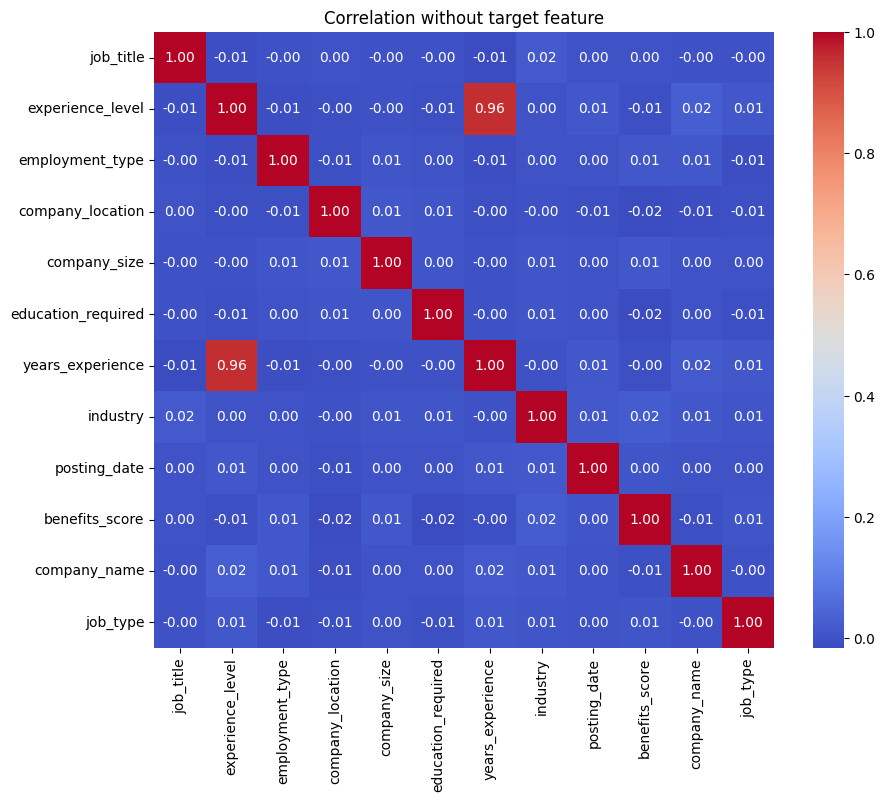

In [2895]:
features = data.columns
features = features[:13]
features_without_target = features[:1].tolist() + features[2:13].tolist()

corr_with_target = data[features_without_target].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_with_target, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation without target feature")
plt.show()

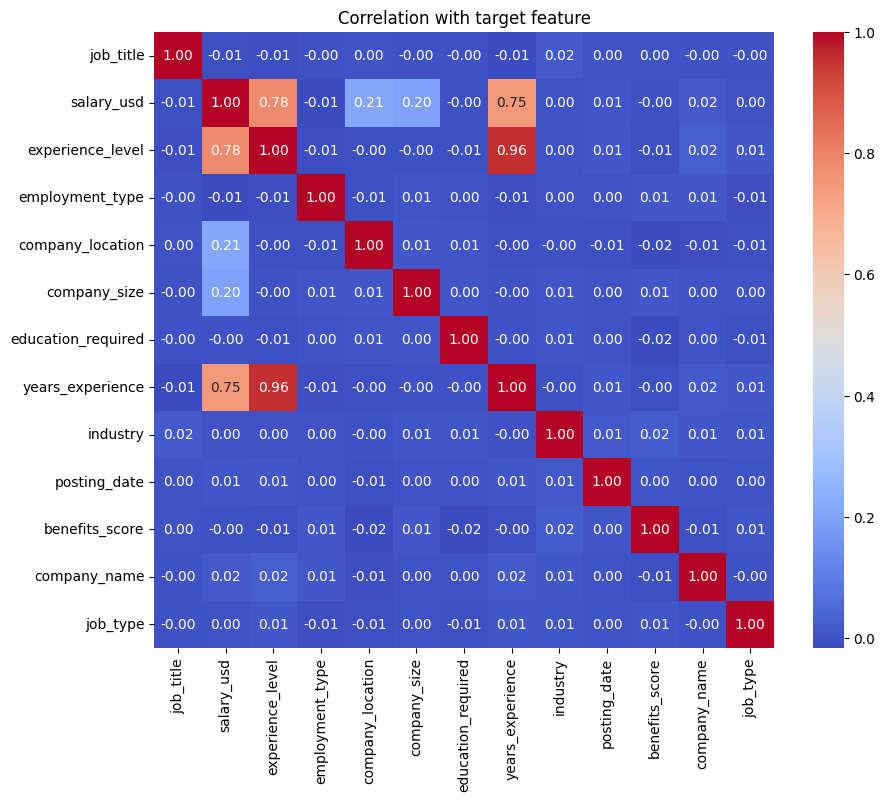

In [2896]:
# Correlation with Target Feature
corr_with_target = data[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_with_target, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation with target feature")
plt.show()

In [2897]:
# dropping the 'years_experince' column as it has a lower correlation with the target feature
data.drop('years_experience', axis = 1, inplace = True)

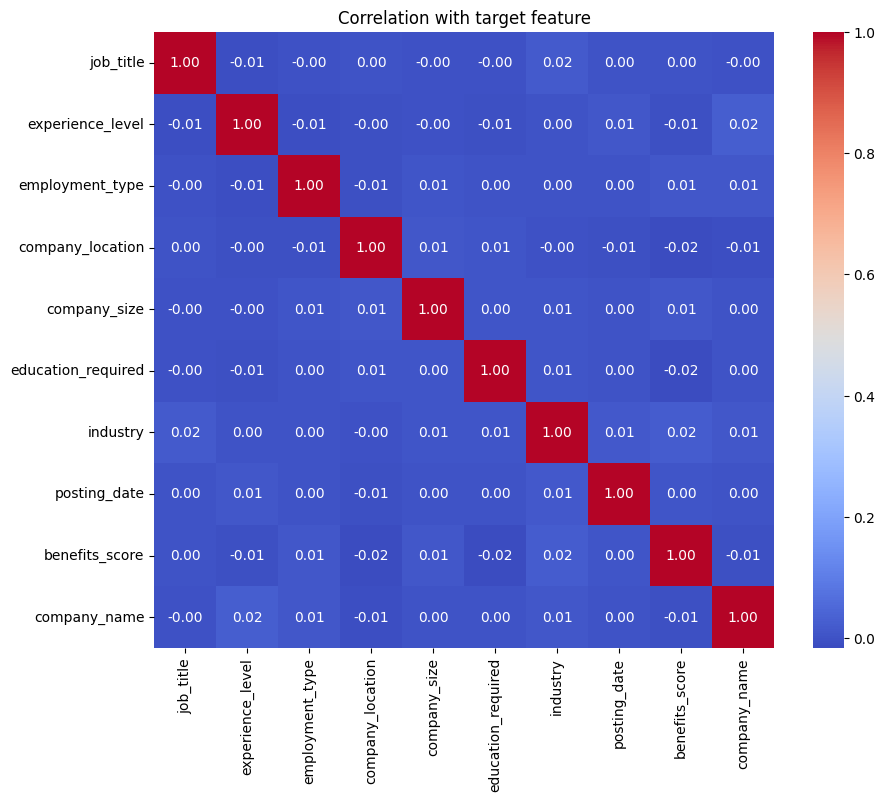

In [2898]:
columns_after_correlation = data.columns
columns_after_correlation = columns_after_correlation[:1].tolist() + columns_after_correlation[2:11].tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(data[columns_after_correlation].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation with target feature")
plt.show()

In [2899]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14043 entries, 0 to 14999
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           14043 non-null  int64  
 1   salary_usd          14043 non-null  float64
 2   experience_level    14043 non-null  int64  
 3   employment_type     14043 non-null  int64  
 4   company_location    14043 non-null  int64  
 5   company_size        14043 non-null  int64  
 6   education_required  14043 non-null  int64  
 7   industry            14043 non-null  int64  
 8   posting_date        14043 non-null  float64
 9   benefits_score      14043 non-null  float64
 10  company_name        14043 non-null  int64  
 11  job_type            14043 non-null  int64  
 12  AWS                 14043 non-null  int64  
 13  Azure               14043 non-null  int64  
 14  Computer Vision     14043 non-null  int64  
 15  Data Visualization  14043 non-null  int64  
 16  Deep Lear

### ML Model

In [2900]:
X = data.drop("salary_usd", axis=1)
y = data["salary_usd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2901]:
# Building the ML Model
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [2902]:
y_pred = model.predict(X_test)
print("Score:", r2_score(y_test, y_pred)*100)

Score: 91.6944045577071


<Figure size 1000x800 with 0 Axes>

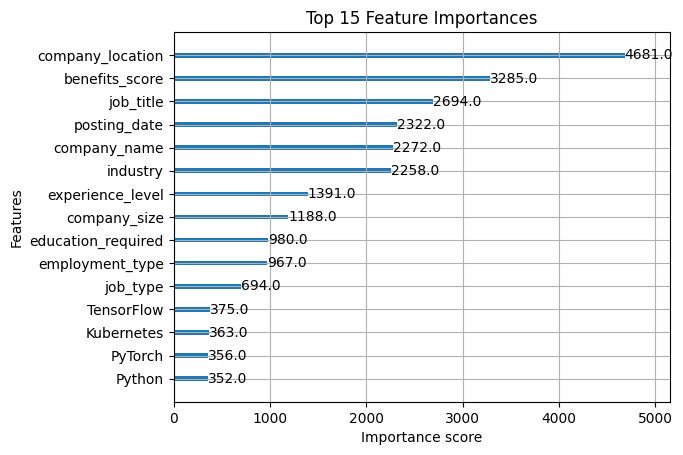

In [2903]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))
plot_importance(model, importance_type='weight', max_num_features=15)
plt.title("Top 15 Feature Importances")
plt.show()